In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')
import pandas as pd
from src.preprocessing import preprocess

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

from src.estimators import (
    doubly_robust_ate,
    regression_adjusted_ate,
    naive_ate,
    cluster_bootstrap_ci,
)

In [2]:
from src.data_loader import load_twins_data

df = load_twins_data()
df = df.dropna(subset=['tobacco', 'alcohol']).reset_index(drop=True)
df['any_exposure'] = ((df['tobacco'] == 1) | (df['alcohol'] == 1)).astype(int)

X, T, Y, exposure, pair_id = preprocess(df)

In [3]:
print(f"X shape: {X.shape}")
print(f"T shape: {T.shape}, T mean: {T.mean():.3f}")
print(f"Y shape: {Y.shape}, Y mean: {Y.mean():.3f}")
print(f"Exposure mean: {exposure.mean():.3f}")
print(f"Number of unique pairs: {len(set(pair_id))}")
print(f"Any NaNs remaining in X: {X.isna().sum().sum()}")

X shape: (17688, 97)
T shape: (17688,), T mean: 0.500
Y shape: (17688,), Y mean: 0.176
Exposure mean: 0.229
Number of unique pairs: 8844
Any NaNs remaining in X: 0


In [4]:
ate = doubly_robust_ate(X, T, Y)
print(f"Doubly Robust ATE estimate: {ate:.4f}")

Doubly Robust ATE estimate: -0.0262


In [5]:
point, ci_low, ci_high, boot_estimates = cluster_bootstrap_ci(X, T, Y, pair_id, n_boot=500)
print(f"DR ATE: {point:.4f}")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

DR ATE: -0.0262
95% CI: [-0.0329, -0.0189]


Propensity score min:    0.4735
Propensity score max:    0.5271
Propensity score mean:   0.5000
Propensity score median: 0.5140
Scores below 0.05: 0
Scores above 0.95: 0


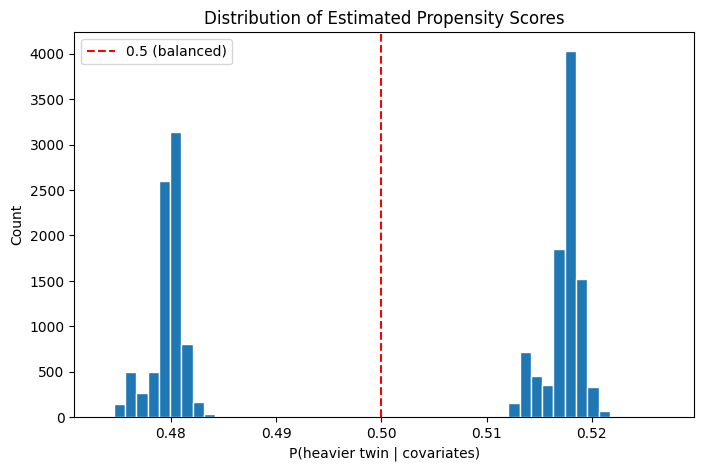

In [ ]:
# Refit the propensity model to inspect the scores
X_arr = np.asarray(X)
T_arr = np.asarray(T)

ps_model = LogisticRegression(penalty=None, max_iter=1000)
ps_model.fit(X_arr, T_arr)
ps = ps_model.predict_proba(X_arr)[:, 1]

# Examining range and summary
print(f"Propensity score min: {ps.min():.4f}")
print(f"Propensity score max: {ps.max():.4f}")
print(f"Propensity score mean: {ps.mean():.4f}")
print(f"Propensity score median: {np.median(ps):.4f}")
print(f"Scores below 0.05: {(ps < 0.05).sum()}")
print(f"Scores above 0.95: {(ps > 0.95).sum()}")

# Creating distribution plot
plt.figure(figsize=(8, 5))
plt.hist(ps, bins=50, edgecolor='white')
plt.axvline(0.5, color='red', linestyle='dashed', label='0.5 (balanced)')
plt.title("Distribution of Estimated Propensity Scores")
plt.xlabel("P(heavier twin | covariates)")
plt.ylabel("Count")
plt.legend()
plt.savefig("../figures/propensity_scores.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Compute all estimates
naive = naive_ate(T, Y)
reg_adj = regression_adjusted_ate(X, T, Y)
dr = doubly_robust_ate(X, T, Y)

print(f"Naive (unadjusted):       {naive:.4f}")
print(f"Regression-adjusted:      {reg_adj:.4f}")
print(f"Doubly Robust (AIPW):     {dr:.4f}")

Naive (unadjusted):       -0.0261
Regression-adjusted:      -0.0263
Doubly Robust (AIPW):     -0.0262
